# Face detection
In this notebook we will use an object detection network to detect faces in images. In this case, we will only need positive samples. The network will be fed with images that contain faces and the coordinates of their bounding boxes. The negative samples are implicitly the rest of the image patches without faces.

Since the architecture and the training of an object detection network is quite complex, you are going to download and learn to use a You Look Only Once (YOLO) network. This notebook reproduces all the steps to build an object detection system from scratch. 

Global requirements:
- git

Python requirements:
- matplotlib
- pytorch
- glob
- opencv
- shapely


## The problem
You have to develop a solution to detect faces in images and to identify if they are using a mask. To this end, you have a dataset of more than 800 annotated images. There are three classes in this dataset: without mask, with mask, and mask weared incorrect.

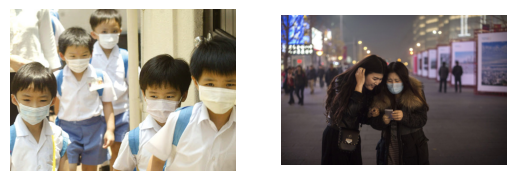

In [1]:
import matplotlib.pyplot as plt


im1 = plt.imread('res/facemask/images/train/maksssksksss230.png')
im2 = plt.imread('res/facemask/images/train/maksssksksss345.png')

fig, ax = plt.subplots(1,2)
ax[0].imshow(im1)
ax[0].axis('off')
ax[1].imshow(im2)
ax[1].axis('off')
plt.show()

The images are annotated in XML following the VOC format:
```
<annotation>
    <folder>images</folder>
    <filename>maksssksksss345.png</filename>
    <size>
        <width>400</width>
        <height>267</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>with_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>186</xmin>
            <ymin>110</ymin>
            <xmax>218</xmax>
            <ymax>142</ymax>
        </bndbox>
    </object>
    <object>
        <name>without_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>148</xmin>
            <ymin>109</ymin>
            <xmax>182</xmax>
            <ymax>136</ymax>
        </bndbox>
    </object>
</annotation>
```

The images for training are stored in the directory `res/facemask/images/train` and the images for validation, in `res/facemask/images/val`. The annotations are stored in the `res/facemask/labels/train` and `res/facemask/labels/val`. The name of the image and its corresponding annotation file is the same but the extension.

The following function reads a xml and returns a list with the coordinates of all the bounding boxes and their corresponding classes:

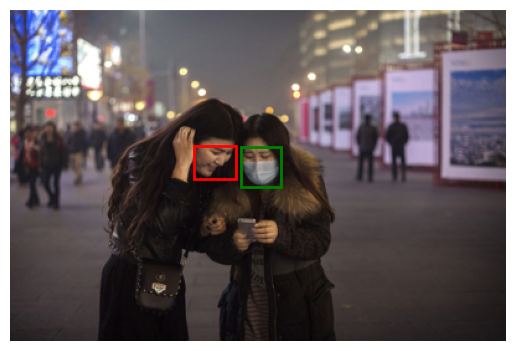

In [2]:
from xml.dom.minidom import parse
from matplotlib.patches import Rectangle
import numpy as np


FACE_MASK_CLASSES = {
    'with_mask': 0,
    'mask_weared_incorrect': 1,
    'without_mask': 2
}
COLORS = {
    0: 'green',
    1: 'purple',
    2: 'red',
}

def parse_xml_voc(filename):
    document = parse(filename)
    
    xmin = document.getElementsByTagName("xmin")
    ymin = document.getElementsByTagName("ymin")
    xmax = document.getElementsByTagName("xmax")
    ymax = document.getElementsByTagName("ymax")
    name = document.getElementsByTagName("name")

    data = np.zeros((len(xmin), 5)) # Label + 4 coordinates
    for idx in range(len(xmin)):
        data[idx, 0] = FACE_MASK_CLASSES[name[idx].firstChild.nodeValue]
        data[idx, 1] = int(xmin[idx].firstChild.nodeValue)
        data[idx, 2] = int(ymin[idx].firstChild.nodeValue)
        data[idx, 3] = int(xmax[idx].firstChild.nodeValue)
        data[idx, 4] = int(ymax[idx].firstChild.nodeValue)
    
    return data

data = parse_xml_voc('res/facemask/labels/train/maksssksksss345.xml')

plt.imshow(im2)
plt.axis('off')
for box in data:
    label = box[0]
    x1, y1, x2, y2 = box[1:]
    # Rectangle( (xmin, ymin), width, height, ...)
    plt.gca().add_patch(Rectangle((x1, y1), x2-x1, y2-y1, 
                              edgecolor=COLORS[label], 
                              facecolor='none',
                              lw=2))
plt.show()
                    

## Step 1: Prepare the environment

You can execute command line instructions from the Jupyter environment. In this notebook, you are going to download the source code of the official YOLOv7 network from github and install its requirements.

In [3]:
!git clone https://github.com/WongKinYiu/yolov7.git

fatal: destination path 'yolov7' already exists and is not an empty directory.


In [4]:
# !python3 -m pip install -r yolov7/requirements.txt

import sys

!{sys.executable} -m pip install -r yolov7/requirements.txt

## Step 2: Prepare the dataset
For each sample, the YOLO network receives a pair of files: the image and its corresponding annotations in a txt file. The name of the image and the txt file should be the same. Each line in the txt file contains the annotation of a region following this format: 
```
label xc yc w h
````
where `xc` and `yc` are the coordinates of the center of a bounding box and `w`and  `h` are its width and height. These four values are relative to size of the image. For example, if the size of the image is 1000x1000 and the center of a bounding box is at (500,500), the relative values are (0.5, 0.5).

### Exercise
Write a function to convert a file from the VOC format to the YOLO format and write it in a specific directory.


In [5]:
import csv

def voc_to_yolo(in_image, in_annotations, out_annotations):
    document = parse(in_annotations)
    
    xmin = document.getElementsByTagName("xmin")
    ymin = document.getElementsByTagName("ymin")
    xmax = document.getElementsByTagName("xmax")
    ymax = document.getElementsByTagName("ymax")
    name = document.getElementsByTagName("name")

    # Read image size
    img = plt.imread(in_image)
    img_height, img_width = img.shape[:2]

    with open(out_annotations, "w", newline="") as f:
        writer = csv.writer(f, delimiter=" ")
        
        for idx in range(len(xmin)):
            class_name = name[idx].firstChild.nodeValue
            label = FACE_MASK_CLASSES[class_name]

            x1 = int(xmin[idx].firstChild.nodeValue)
            y1 = int(ymin[idx].firstChild.nodeValue)
            x2 = int(xmax[idx].firstChild.nodeValue)
            y2 = int(ymax[idx].firstChild.nodeValue)

            # Convert VOC coordinates to YOLO coordinates
            box_width = x2 - x1
            box_height = y2 - y1

            x_center = x1 + box_width / 2
            y_center = y1 + box_height / 2

            # Normalize values with respect to image size
            xc = x_center / img_width
            yc = y_center / img_height
            w = box_width / img_width
            h = box_height / img_height

            writer.writerow([label, xc, yc, w, h])

Check the contents of the file (only works in linux/osx):

In [6]:
# %cat res/facemask/labels/train/maksssksksss345.txt

voc_to_yolo(
    "res/facemask/images/train/maksssksksss345.png",
    "res/facemask/labels/train/maksssksksss345.xml",
    "res/facemask/labels/train/maksssksksss345.txt"
)

with open("res/facemask/labels/train/maksssksksss345.txt", "r") as f:
    print(f.read())

0 0.505 0.47191011235955055 0.08 0.1198501872659176
2 0.4125 0.45880149812734083 0.085 0.10112359550561797



### Exercise

Transform all the xml in the validation and train datasets into YOLO format. Store the txt files in the same directories as the xml files (`res/facemask/labels/train` or `res/facemask/labels/val`).

*Hint*: in previous notebooks we have used the library `glob` for reading files from a directory.

#### Converting all VOC annotations to YOLO format

After checking the conversion for one example, we now apply the same process to all annotation files in the training and validation sets.

Each XML file is converted into a TXT file with the same base name. The output TXT files are stored in the same annotation directories, because YOLO expects each image to have a corresponding label file with the same name.

In [7]:
import glob
import os

def convert_dataset_annotations(image_dir, annotation_dir):
    xml_files = glob.glob(os.path.join(annotation_dir, "*.xml"))

    for xml_file in xml_files:
        base_name = os.path.splitext(os.path.basename(xml_file))[0]

        image_file = os.path.join(image_dir, base_name + ".png")
        txt_file = os.path.join(annotation_dir, base_name + ".txt")

        voc_to_yolo(
            in_image=image_file,
            in_annotations=xml_file,
            out_annotations=txt_file
        )

    print(f"Converted {len(xml_files)} annotation files in {annotation_dir}")


convert_dataset_annotations(
    image_dir="res/facemask/images/train",
    annotation_dir="res/facemask/labels/train"
)

convert_dataset_annotations(
    image_dir="res/facemask/images/val",
    annotation_dir="res/facemask/labels/val"
)

Converted 700 annotation files in res/facemask/labels/train
Converted 153 annotation files in res/facemask/labels/val


Check the creation of files (only works in linux/osx):

In [8]:
# !echo "Number of xml files:"
# %ls res/facemask/labels/*/*.xml |wc -l
# !echo "Number of txt files:"
# %ls res/facemask/labels/*/*.txt |wc -l

xml_files = glob.glob("res/facemask/labels/*/*.xml")
txt_files = glob.glob("res/facemask/labels/*/*.txt")

print("Number of xml files:", len(xml_files))
print("Number of txt files:", len(txt_files))

Number of xml files: 853
Number of txt files: 853


## Step 2: Set up training

You will not need to write any code to train a YOLO network. Instead, you will use a predefined architecture and tweak it to fit your problem. 

This step requires that you copy and edit some files in your filesystem using a text editor outside the Jupyter environment.

### Exercise
Follow the next steps to set up the training stage:

1. Create a file `res/facemask/facemask.yaml` where you will define the absolute path to your files  and the features of your dataset as follows:

```
train: /absolute/path/to/res/facemask/images/train
val: /absolute/path/to/res/facemask/images/val

nc: 3
names: ['with mask', 'mask weared incorrect', 'without mask']
```
**Important**: the training will not work unless you write in this file the **actual absolute path** to your files. 

2. Define the architecture of your network and adapt it to the number of classes of this problem. Copy the file `yolov7/cfg/training/yolov7.yaml`to  `res/facemask/yolov7_facemask.yaml` and edit the number of classes (3 instead of 80).

Run the following lines to check the files (only works in linux/osx).

#### YOLO training configuration

Before training YOLOv7, we need to create two configuration files.

First, we create a dataset YAML file with the absolute paths to the training and validation images. This file also defines the number of classes and their names.

Second, we copy the original YOLOv7 architecture configuration and modify the number of output classes from 80 to 3, because our dataset contains three face-mask classes.

In [9]:
from pathlib import Path
import shutil

# Base path of the current project
base_path = Path.cwd()

print("Current working directory:")
print(base_path)

facemask_path = base_path / "res" / "facemask"

train_images_path = facemask_path / "images" / "train"
val_images_path = facemask_path / "images" / "val"

print("Train images path exists:", train_images_path.exists())
print("Validation images path exists:", val_images_path.exists())

Current working directory:
c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII
Train images path exists: True
Validation images path exists: True


In [10]:
# Create facemask.yaml using absolute paths
facemask_yaml_path = facemask_path / "facemask.yaml"

facemask_yaml_content = f"""train: {train_images_path.as_posix()}
val: {val_images_path.as_posix()}

nc: 3
names: ['with mask', 'mask weared incorrect', 'without mask']
"""

with open(facemask_yaml_path, "w") as f:
    f.write(facemask_yaml_content)

print(f"Created file: {facemask_yaml_path}")
print()
print(facemask_yaml_content)

Created file: c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\res\facemask\facemask.yaml

train: c:/Users/Hugo/OneDrive - Universidade de Santiago de Compostela/IA/CVII/res/facemask/images/train
val: c:/Users/Hugo/OneDrive - Universidade de Santiago de Compostela/IA/CVII/res/facemask/images/val

nc: 3
names: ['with mask', 'mask weared incorrect', 'without mask']



In [11]:
# Copy YOLOv7 architecture config and adapt it to 3 classes
source_cfg = base_path / "yolov7" / "cfg" / "training" / "yolov7.yaml"
target_cfg = facemask_path / "yolov7_facemask.yaml"

shutil.copy(source_cfg, target_cfg)

with open(target_cfg, "r") as f:
    cfg_text = f.read()

cfg_text = cfg_text.replace("nc: 80", "nc: 3")

with open(target_cfg, "w") as f:
    f.write(cfg_text)

print(f"Created file: {target_cfg}")

Created file: c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\res\facemask\yolov7_facemask.yaml


In [12]:
# !echo "Checking files:\n\n=== facemask.yaml ===\n"
# %cat res/facemask/facemask.yaml

print("=== facemask.yaml ===")
with open(facemask_yaml_path, "r") as f:
    print(f.read())

=== facemask.yaml ===
train: c:/Users/Hugo/OneDrive - Universidade de Santiago de Compostela/IA/CVII/res/facemask/images/train
val: c:/Users/Hugo/OneDrive - Universidade de Santiago de Compostela/IA/CVII/res/facemask/images/val

nc: 3
names: ['with mask', 'mask weared incorrect', 'without mask']



In [13]:
# !echo "=== yolov7_facemask.yaml ===\n"
# !head -n 10 res/facemask/yolov7_facemask.yaml

print("=== yolov7_facemask.yaml first lines ===")
with open(target_cfg, "r") as f:
    for i in range(10):
        print(f.readline(), end="")

=== yolov7_facemask.yaml first lines ===
# parameters
nc: 3  # number of classes
depth_multiple: 1.0  # model depth multiple
width_multiple: 1.0  # layer channel multiple

# anchors
anchors:
  - [12,16, 19,36, 40,28]  # P3/8
  - [36,75, 76,55, 72,146]  # P4/16
  - [142,110, 192,243, 459,401]  # P5/32


## Step 3: Train the network

Once both the architecture and dataset were defined, you can train the YOLO network. To this end, you are going to use the script `yolov7/train.py` and the weights of a pretrained network (`res/facemask/yolov7_weights.pt`). 

### Exercise
Run the following command to train the YOLO network that you have configured for 3 epochs. 

**Important**: check that all the files are stored in the appropriate paths. 

**Note**: the training can last several minutes (even hours) if it is run on a CPU. 

The results of the training (info, graphs, weights, ...)  will be stored in the directory `runs/trainings/facemask??` where `??` is a number.

In [14]:
# %cd yolov7
# !python3 train.py --img-size 640 --cfg ../res/facemask/yolov7_facemask.yaml --hyp data/hyp.scratch.custom.yaml --batch 8 --epochs 3 --data ../res/facemask/facemask.yaml --weights ../res/facemask/yolov7_weights.pt --workers 8 --name facemask

%cd yolov7

c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\yolov7


In [15]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce GTX 1650


In [16]:
import glob
import os
import numpy as np

bad_files = []
empty_files = 0
total_boxes = 0

label_files = glob.glob("res/facemask/labels/*/*.txt")

for label_file in label_files:
    with open(label_file, "r") as f:
        lines = [line.strip() for line in f.readlines()]

    if len(lines) == 0:
        empty_files += 1
        continue

    for line_number, line in enumerate(lines, start=1):
        if line == "":
            bad_files.append((label_file, line_number, "empty line"))
            continue

        parts = line.split()

        if len(parts) != 5:
            bad_files.append((label_file, line_number, f"wrong number of values: {parts}"))
            continue

        try:
            label = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:])
        except ValueError:
            bad_files.append((label_file, line_number, f"cannot parse values: {parts}"))
            continue

        if label not in [0, 1, 2]:
            bad_files.append((label_file, line_number, f"wrong class: {label}"))

        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
            bad_files.append((label_file, line_number, f"wrong coordinates: {x}, {y}, {w}, {h}"))

        total_boxes += 1

print("Number of txt files:", len(label_files))
print("Number of empty txt files:", empty_files)
print("Total boxes:", total_boxes)
print("Number of problems:", len(bad_files))

bad_files[:20]

Number of txt files: 0
Number of empty txt files: 0
Total boxes: 0
Number of problems: 0


[]

In [17]:
#!python train.py --img-size 640 --cfg ../res/facemask/yolov7_facemask.yaml --hyp data/hyp.scratch.custom.yaml --batch 4 --epochs 3 --data ../res/facemask/facemask.yaml --weights ../res/facemask/yolov7_weights.pt --workers 0 --name facemask_fixed

## Step 4: Check the results

Once the training is finished, you can process a new image to detect faces with or without masks. The following function gets the predictions of a YOLO network on an input image.

In [18]:
import time
import torch
import cv2
import skimage.transform
from utils.torch_utils import select_device
from utils.datasets import letterbox
from models.experimental import attempt_load


def get_predictions(device, weights, image_paths, imgsz=640):
    
    model = attempt_load(weights, map_location=device)
    stride = int(model.stride.max())
    half = device.type != 'cpu' 
    if half:
        model.half()
    
    image_predictions = []
    for path in image_paths:
        img = plt.imread(path)
        if img.shape[2] > 3:
            img = img[:,:,:3]
        # Resize image and add suitable paddings
        img = letterbox(img, (imgsz, imgsz), stride=stride)[0] 
        img = np.ascontiguousarray(img.transpose(2,0,1))
        img = torch.from_numpy(img).to(device)
        img = torch.unsqueeze(img, 0)
        img = img.half() if half else img.float()  # uint8 to fp16/32
        t1 = time.time()
        with torch.no_grad(): 
            model_predictions = model(img,augment=True)[0]
        t2 = time.time()
        # predictions format: [xc, yc, w, h, object confidence, confidences of each class]        
        predictions = model_predictions[0].detach().cpu().numpy()
        print(f"Detection in {t2-t1}s")
        image_predictions.append(predictions)
    return image_predictions

        
        
    
if torch.cuda.is_available():
    device = select_device("")
else:
    device = select_device("cpu")

image_paths = ['../res/facemask/images/val//maksssksksss788.png', 
               '../res/facemask/images/val/maksssksksss792.png']
image_predictions = get_predictions(device, '../res/facemask/yolov7_weights.pt',image_paths)
    

c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\yolov7\models\experimental.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(w,

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Detection in 0.6641690731048584s
Detection in 0.4415595531463623s


### Exercise
Implement a function to detect faces in an image given the predictions computed by the network. Compute the confidence of a region as the product of the object confidence and the class confidence and use a threshold to discard regions with a low score. If two or more regions overlap, take the region with the highest score only. 

*Hint*: the library `shapely` provides functions to compute the intersection between two boxes, e.g.:

In [19]:
from shapely.geometry import box
#          x1,y1,x2,y2
box1 = box(0, 0, 10, 10)
box2 = box(5, 5, 10, 10)
box3 = box(11, 11, 20, 20)

print(f"Box1-Box2 intersected = {box1.intersects(box2)} | Intersection area: {box1.intersection(box2).area} | IoU: {box1.intersection(box2).area/box1.union(box2).area}")
print(f"Box1-Box3 intersected = {box1.intersects(box3)} | Intersection area: {box1.intersection(box3).area} | IoU: {box1.intersection(box3).area/box1.union(box3).area}")


Box1-Box2 intersected = True | Intersection area: 25.0 | IoU: 0.25
Box1-Box3 intersected = False | Intersection area: 0.0 | IoU: 0.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


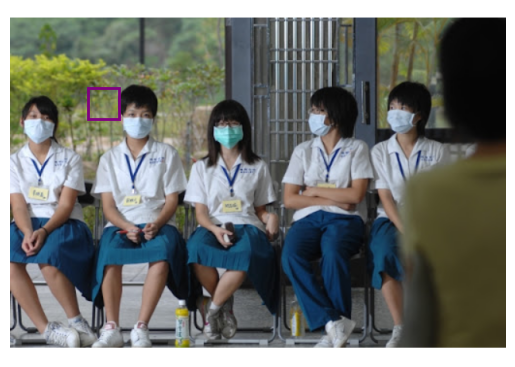

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


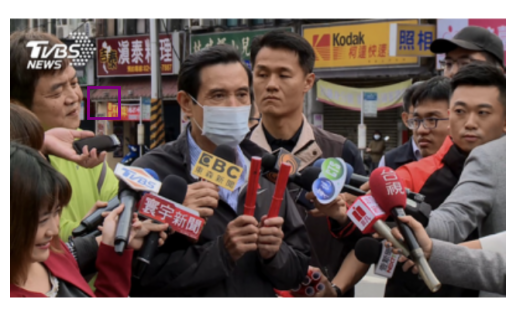

In [20]:
%matplotlib inline

import matplotlib.pyplot as plt
from shapely.geometry import box


def detect_faces(predictions, imgsz=640, threshold=0.9):
    # Write your code here
    
    # Row format: x1, y1, x2, y2, score, label
    faces = np.zeros((1,6))
    faces[0,:] = np.array([100, 100, 140, 140, 1, 1])
    
    return faces
        

for image_path,predictions in zip(image_paths, image_predictions):
    faces = detect_faces(predictions)

    img = plt.imread(image_path)
    img = letterbox(img, (640, 640))[0]
    plt.imshow(img)
    plt.axis('off')
    for x1,y1,x2,y2,score,label in faces:
        plt.gca().add_patch(Rectangle((x1, y1), x2-x1, y2-y1, 
                            edgecolor=COLORS[label], 
                            facecolor='none',
                            lw=2))
    
    plt.show()
